## Load Libraries


In [2]:
# Data manipulation libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set visualization style
sns.set(style="whitegrid")

## Load Data file


In [3]:
# Load the dataset
# Make sure the csv file is in the same folder as your notebook
df = pd.read_csv('employment_sector.csv')

# Quick look at the data
print(df.head())

         date       sector   sex  proportion
0  2001-01-01  agriculture  both        15.1
1  2002-01-01  agriculture  both        14.9
2  2003-01-01  agriculture  both        14.3
3  2004-01-01  agriculture  both        14.6
4  2005-01-01  agriculture  both        14.6


In [4]:
# Balanced dataset check
print(df['sector'].value_counts())

sector
agriculture    66
industry       66
services       66
Name: count, dtype: int64


## Data Preprocessing

In [5]:
# Data preprocessing
df = df.dropna() # Drop rows with missing values
df['date'] = pd.to_datetime(df['date'])
df['Year'] = df['date'].dt.year

# SVM requires numbers, so we need to encode categorical variables
encoder = LabelEncoder()
df['sex_encoded'] = encoder.fit_transform(df['sex'])

# Display the mapping of original categories to encoded values
print("Sex Mapping:", 
      dict(
        zip(encoder.classes_, encoder.transform(encoder.classes_))
        )
    )

# Use Year, Sex, and Proportion to predict the Sector
X = df[['Year', 'sex_encoded', 'proportion']]
y = df['sector']


Sex Mapping: {'both': np.int64(0), 'female': np.int64(1), 'male': np.int64(2)}


## Split Data and Train Model

In [6]:
# Reproducibility and splitting the data into train (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y # to maintain class distribution
    )

# Scaling the features, so that the large numbers do not dominate the small ones
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Hyperparameter tuning using Grid Search
#NOTE: Iterate over different combinations of hyperparameters to find the best model.
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto',0.001, 0.01, 0.1], 
    'kernel': ['linear', 'rbf', 'poly']
}

In [7]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

# Set up the grid search for the best hyperparameters with 10-fold cross-validation
grid_search = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid,
    cv=10,          # 10-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,      # Use all CPU cores
    verbose=1       # Show progress
)

# Fit the grid search to the training data
print("Performing hyperparameter tuning with 10-fold CV...")
grid_search.fit(X_train_scaled, y_train)

# Retrieve and display the best hyperparameters and corresponding score
best_params = grid_search.best_params_
best_cv_score = grid_search.best_score_

print(f"\n--- Best Hyperparameters from CV ---")
print(f"Best Parameters: {best_params}")
print(f"Best CV Accuracy: {best_cv_score * 100:.2f}%")


Performing hyperparameter tuning with 10-fold CV...
Fitting 10 folds for each of 45 candidates, totalling 450 fits

--- Best Hyperparameters from CV ---
Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Accuracy: 100.00%


In [8]:
print("\nTraining final model with best parameters...")
final_model = SVC(**best_params, random_state=42)
final_model.fit(X_train_scaled, y_train)  # Use all training data


Training final model with best parameters...


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## Evaluation


In [9]:
# Evaluate the final model on the test set
print("\n--- Final Evaluation on Test Set ---")
y_pred = final_model.predict(X_test_scaled)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


--- Final Evaluation on Test Set ---
Test Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

 agriculture       1.00      1.00      1.00        13
    industry       1.00      1.00      1.00        13
    services       1.00      1.00      1.00        14

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



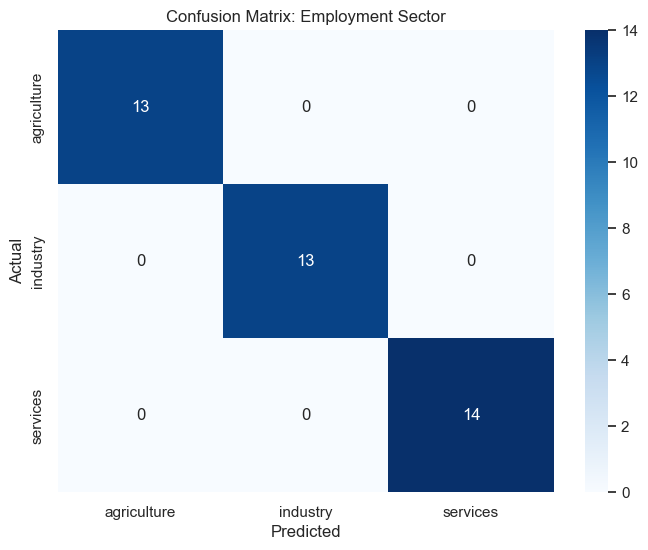

In [10]:
# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=final_model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=final_model.classes_, 
            yticklabels=final_model.classes_)
plt.title('Confusion Matrix: Employment Sector')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

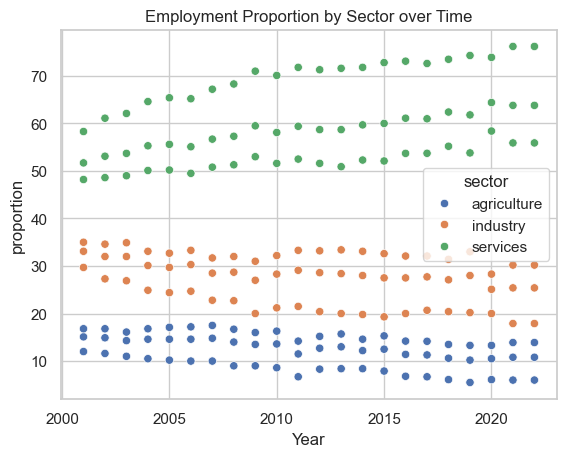

In [11]:
# Visualize the proportion of employment in each sector over the years
sns.scatterplot(data=df, x='Year', y='proportion', hue='sector')
plt.title('Employment Proportion by Sector over Time')
plt.show()

In [15]:
# --- Setup Grid ---
# Create a meshgrid of points to cover the whole plot area
x_min, x_max = X['Year'].min() - 1, X['Year'].max() + 1
y_min, y_max = X['proportion'].min() - 5, X['proportion'].max() + 5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# --- Prepare Grid Data ---
# We use 2 features: Year, Proportion
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Scale the grid points (MUST use the same scaler as training!)
grid_points_scaled = scaler.transform(grid_points)

# This returns strings: ['agriculture', 'industry', ...]
Z_text = final_model.predict(grid_points_scaled)

# We fit a LabelEncoder to turn 'agriculture' -> 0, etc.
le_sector = LabelEncoder()
le_sector.fit(df['sector']) # Learn the mapping (e.g. Agri=0, Ind=1, Serv=2)

# Transform the text predictions to numbers
Z_numeric = le_sector.transform(Z_text)
Z = Z_numeric.reshape(xx.shape)

# --- Plot ---
plt.figure(figsize=(10, 6))

# Now Z contains numbers, so contourf works!
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# Overlay the actual data points
# We plot all points regardless of sex
subset_y_numeric = le_sector.transform(df['sector'])

scatter = plt.scatter(df['Year'], 
                      df['proportion'], 
                      c=subset_y_numeric, 
                      cmap=plt.cm.coolwarm, 
                      edgecolors='k', s=50)

# Add Legend and Labels
plt.title(f'SVM Decision Regions (All Data)')
plt.xlabel('Year')
plt.ylabel('Proportion (%)')

# Create legend
handles, _ = scatter.legend_elements()
plt.legend(handles, le_sector.classes_, title="Sector")

plt.show()

e:\school\uni\sem 7\ML\assignment\code\svm\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


ValueError: X has 2 features, but StandardScaler is expecting 3 features as input.

List of Sex categories: ['both', 'female', 'male']


e:\school\uni\sem 7\ML\assignment\code\svm\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


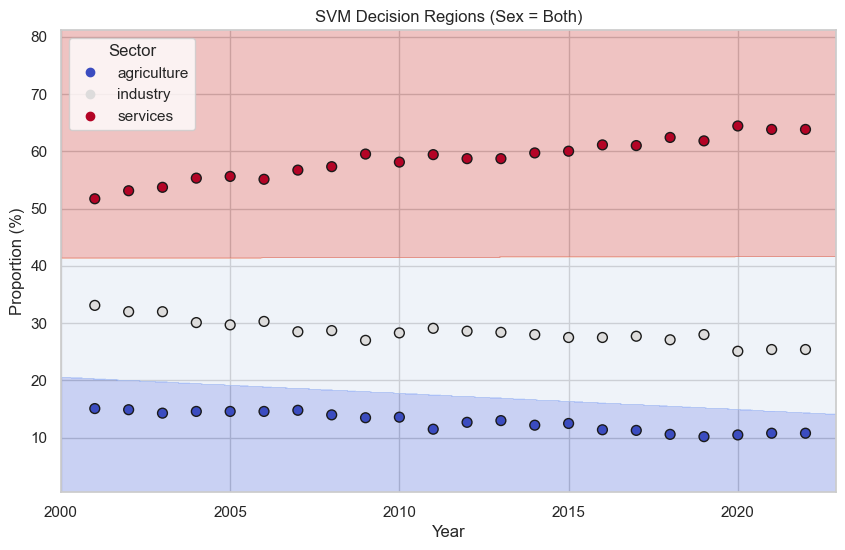

e:\school\uni\sem 7\ML\assignment\code\svm\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


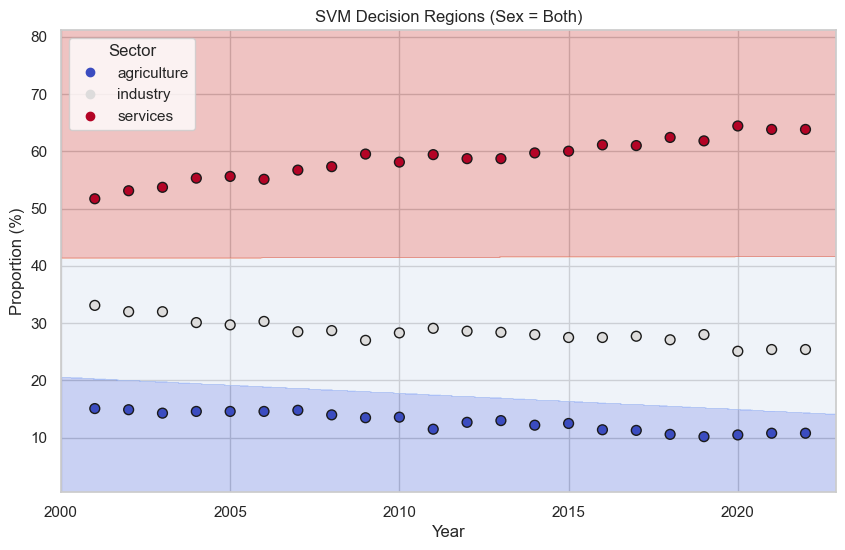

e:\school\uni\sem 7\ML\assignment\code\svm\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


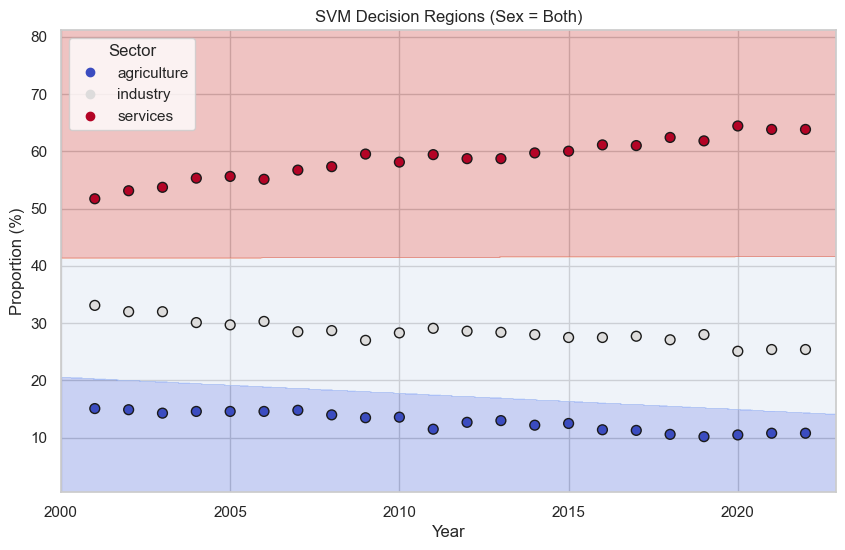

In [14]:
# --- Setup Grid ---
# Create a meshgrid of points to cover the whole plot area

x_min, x_max = X['Year'].min() - 1, X['Year'].max() + 1
y_min, y_max = X['proportion'].min() - 5, X['proportion'].max() + 5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# --- Prepare Grid Data ---
# We must provide 3 features: Year, Sex, Proportion
# We fix Sex = 0 (Both) to visualize a 2D slice
fixed_sex = 0 

grid_points = np.c_[xx.ravel(), np.full(xx.ravel().shape, fixed_sex), yy.ravel()]

# Scale the grid points (MUST use the same scaler as training!)
grid_points_scaled = scaler.transform(grid_points)

# This returns strings: ['agriculture', 'industry', ...]
Z_text = final_model.predict(grid_points_scaled)

# We fit a LabelEncoder to turn 'agriculture' -> 0, etc.
le_sector = LabelEncoder()
le_sector.fit(df['sector']) # Learn the mapping (e.g. Agri=0, Ind=1, Serv=2)

# Transform the text predictions to numbers
Z_numeric = le_sector.transform(Z_text)
Z = Z_numeric.reshape(xx.shape)

# --- Plot ---
plt.figure(figsize=(10, 6))

# Now Z contains numbers, so contourf works!
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# Overlay the actual data points (optional, but looks nice)
# We only plot points where Sex == 'both' (which is encoded as 2)
subset_mask = (df['sex_encoded'] == 0)
subset_y_numeric = le_sector.transform(df.loc[subset_mask, 'sector'])

scatter = plt.scatter(df.loc[subset_mask, 'Year'], 
                      df.loc[subset_mask, 'proportion'], 
                      c=subset_y_numeric, 
                      cmap=plt.cm.coolwarm, 
                      edgecolors='k', s=50)

# Add Legend and Labels
plt.title(f'SVM Decision Regions (Sex = Both)')
plt.xlabel('Year')
plt.ylabel('Proportion (%)')

# Create legend
handles, _ = scatter.legend_elements()
plt.legend(handles, le_sector.classes_, title="Sector")

plt.show()

e:\school\uni\sem 7\ML\assignment\code\svm\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
e:\school\uni\sem 7\ML\assignment\code\svm\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
e:\school\uni\sem 7\ML\assignment\code\svm\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


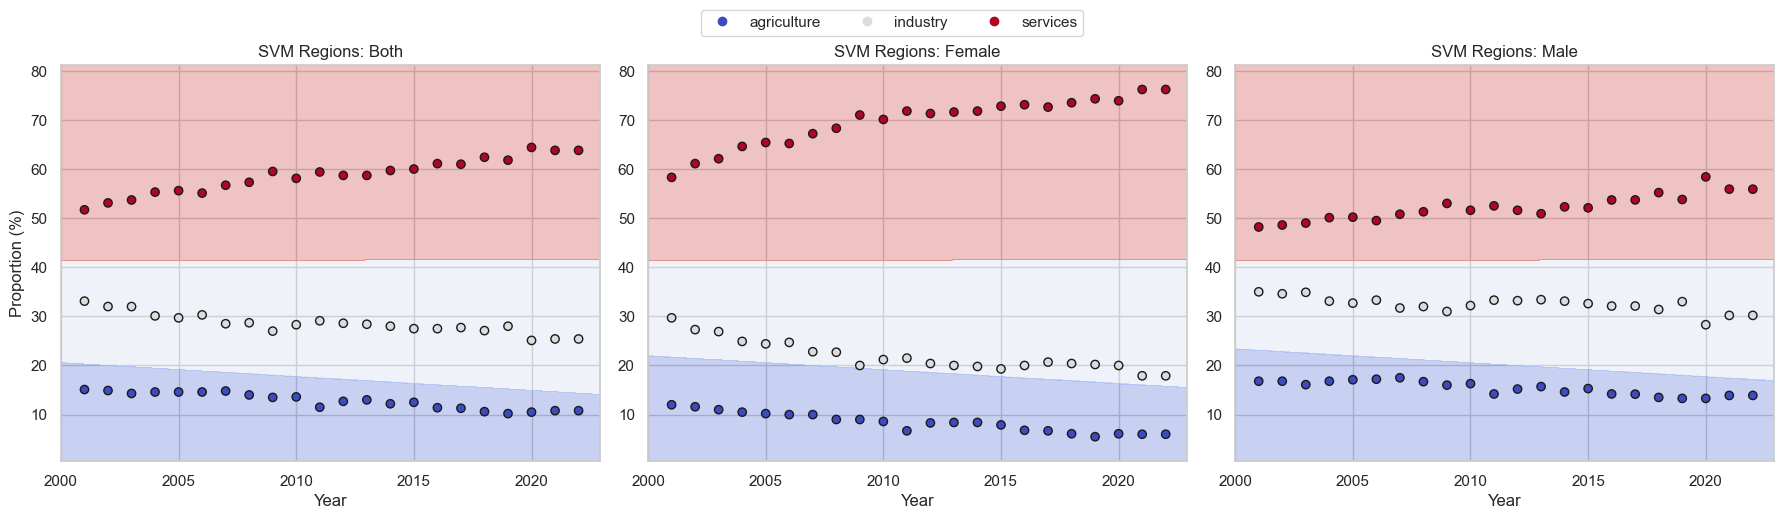

In [12]:
# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# The numbers for our classes (0=Both, 1=Female, 2=Male - strictly alphabetical)
genders = {0: 'Both', 1: 'Female', 2: 'Male'}

for sex_code, sex_label in genders.items():
    ax = axes[sex_code] # Select the right chart
    
    # 1. Create the Grid for THIS specific gender
    grid_points = np.c_[xx.ravel(), np.full(xx.ravel().shape, sex_code), yy.ravel()]
    
    # 2. Predict (Scale first!)
    Z_text = final_model.predict(scaler.transform(grid_points))
    Z_numeric = le_sector.transform(Z_text).reshape(xx.shape)
    
    # 3. Plot the Regions
    ax.contourf(xx, yy, Z_numeric, alpha=0.3, cmap=plt.cm.coolwarm)
    
    # 4. Plot the Actual Data Points for THIS gender
    subset = df[df['sex_encoded'] == sex_code]
    subset_y = le_sector.transform(subset['sector'])
    
    scatter = ax.scatter(subset['Year'], subset['proportion'], 
                         c=subset_y, cmap=plt.cm.coolwarm, edgecolors='k')
    
    ax.set_title(f'SVM Regions: {sex_label}')
    ax.set_xlabel('Year')
    if sex_code == 0: ax.set_ylabel('Proportion (%)') # Only label Y on the first one

# Add a single legend for the whole figure
handles, _ = scatter.legend_elements()
fig.legend(handles, le_sector.classes_, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3)

plt.tight_layout()
plt.show()